In [19]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
from pathlib import Path
import glob
import math

import matplotlib.pyplot as plt
import seaborn as sns

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables




import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [20]:
import polars as pl
from pathlib import Path

def load_maestro_producto(refresh: bool = False) -> pl.LazyFrame:
    BASE = Path("../data/raw")
    MP_PATH = BASE / "maestro_producto.parquet"

    if refresh:
        query = """
        SELECT
            *
        FROM `bold-momentum-270218.bo_data.maestro_producto`
        WHERE CAST(ano_temporada AS INT64) >= 2015
        """
        df = read_data(query=query, credentials=CREDENTIALS_GBQ, project_id=PROJECT_ID_GBQ)
        MP_PATH.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(MP_PATH, compression="zstd")

    if not MP_PATH.exists():
        raise FileNotFoundError(f"No existe {MP_PATH}. Ejecuta con refresh=True al menos una vez.")

    mp_lf = (
        pl.scan_parquet(str(MP_PATH))
        .with_columns(
            pl.col("cod_producto").cast(pl.Utf8),
            pl.col("cod_depto").cast(pl.Int32),
            pl.col("cod_linea").cast(pl.Int32),
            pl.col("cod_grupo").cast(pl.Int32),
            pl.col("cod_marca").cast(pl.Int32),
            pl.col("cod_division").cast(pl.Int32),
            pl.col("cod_temporada").cast(pl.Int32),
            pl.col("ano_temporada").cast(pl.Int16),
            pl.col("nombre_depto").cast(pl.Categorical),
            pl.col("nombre_linea").cast(pl.Categorical),
            pl.col("nombre_grupo").cast(pl.Categorical),
            pl.col("nombre_marca").cast(pl.Categorical),
            pl.col("nombre_division").cast(pl.Categorical),
            pl.col("nombre_temporada").cast(pl.Categorical),
        )
        .select([
            "cod_producto",
            "cod_depto","nombre_depto",
            "cod_linea","nombre_linea",
            "cod_grupo","nombre_grupo",
            "cod_marca","nombre_marca",
            "cod_division","nombre_division",
            "cod_temporada","nombre_temporada",
            "ano_temporada",
        ])
    )
    return mp_lf

In [21]:
from pathlib import Path
import polars as pl

base_path = Path("../data/processed/weekly_sales_by_season")
seasons = ["Invierno"]
years = {"2023", "2024", "2025"}  # strings para matchear en el nombre

# Selecciona paths por nombre (como tu código en pandas)
paths = []
for season in seasons:
    season_path = base_path / season
    for file in season_path.glob("*.parquet"):
        if any(year in file.name for year in years):
            paths.append(str(file))

if not paths:
    raise ValueError("No se encontraron archivos para las temporadas y años indicados.")

data_sales_raw = pl.scan_parquet(paths).with_columns(pl.col("cod_producto").cast(pl.Utf8))

data_sales = data_sales_raw.join(
        load_maestro_producto(refresh=False),
        on=["cod_producto"],
        how="left",)

data_sales = data_sales.with_columns(
    (
        pl.datetime(pl.col("cod_ano_comercial"), 1, 4)  # 4 de enero → semana ISO 1
        .dt.truncate("1w")                              # bajar al lunes
        + (pl.col("cod_semana") - 1) * pl.duration(weeks=1)
    ).alias("week_start_date")
)

In [22]:
sample = data_sales.filter(
    (pl.col("nombre_depto") == "Juvenil mujer") |
    (pl.col("nombre_depto") == "Juvenil hombres") |
    (pl.col("nombre_depto") == "Formal hombres")
).collect()

# Forecast

In [23]:
data_sales = (
    sample
    .group_by(
        [
            "cod_temporada", "nombre_temporada", "ano_temporada",
            "cod_depto", "nombre_depto",
            "cod_linea", "nombre_linea",
            "cod_talla",
            "cod_sucursal",
            "cod_ano_comercial",
            "cod_semana",
            "week_start_date",
        ]
    )
    .agg(
        pl.col("flag_inventory_available").sum().alias("n_skus_with_inventory"),
        pl.col("flag_without_first_sale").sum().alias("n_skus_without_first_sale"),
        pl.col("flag_sku_arrival").sum().alias("n_skus_arrival"),
        pl.col("stock_start_week").sum().alias("stock_start_week"),
        pl.col("stock_end_week").sum().alias("stock_end_week"),
        pl.col("weekly_available_stock").sum().alias("weekly_available_stock"),
        pl.col("weekly_sales").sum().alias("weekly_sales"),
        
        # --- Calcular precio ponderado ---
        (pl.col("stock_start_week") * pl.col("mnt_precio_vigente")).sum().alias("sum_stock_price"),
    )
    .with_columns(
        (pl.col("sum_stock_price") / pl.col("stock_start_week")).alias("precio_ponderado")
    )
    .drop("sum_stock_price")  # opcional, para dejar solo el final
    .sort(
        by=[
            "cod_temporada", "nombre_temporada", "ano_temporada",
            "cod_depto", "nombre_depto",
            "cod_linea", "nombre_linea",
            "cod_talla",
            "cod_sucursal",
            "cod_ano_comercial",
            "cod_semana",
        ]
    )
)


In [24]:
import polars as pl
import numpy as np

# --- Ciclo anual (sin/cos) ---
data_sales = data_sales.with_columns([
    (np.sin(2 * np.pi * pl.col("cod_semana") / 52)).alias("semana_sin"),
    (np.cos(2 * np.pi * pl.col("cod_semana") / 52)).alias("semana_cos"),
])

# --- Calendario ---
data_sales = data_sales.with_columns([
    pl.col("week_start_date").dt.month().alias("mes"),
    (((pl.col("week_start_date").dt.month() - 1) // 3) + 1).alias("trimestre")
])

# --- Orden temporal ---
keys = ["cod_sucursal", "cod_talla"]
sort_keys = [
    "cod_temporada", "ano_temporada",
    "cod_depto", "cod_linea",
    "cod_talla", "cod_sucursal",
    "week_start_date",
]
data_sales = data_sales.sort(sort_keys)

# --- Lags ---
for w in [1, 2, 4, 8, 12]:
    data_sales = data_sales.with_columns(
        pl.col("weekly_sales").shift(w).over(keys).alias(f"lag_{w}")
    )

# --- Rolling mean/std (con shift para no mirar semana actual) ---
for w in [4, 8, 12]:
    data_sales = data_sales.with_columns([
        pl.col("weekly_sales")
        .rolling_mean(window_size=w, min_periods=2)
        .shift(1)
        .over(keys)
        .alias(f"rmean_{w}"),

        pl.col("weekly_sales")
        .rolling_std(window_size=w, min_periods=2)
        .shift(1)
        .over(keys)
        .alias(f"rstd_{w}")
    ])

# --- Momentum ---
data_sales = data_sales.with_columns(
    (pl.col("rmean_4") / pl.col("rmean_12")).alias("momentum_4_12")
)

# --- Calcular week_end_date ---
data_sales = data_sales.with_columns(
    (pl.col("week_start_date") + pl.duration(days=6)).alias("week_end_date")
)

# --- is_payday ---
# Función vectorizada: calculamos si week_start_date o week_end_date caen en la ventana
# (últimos 2 hábiles del mes o primeros 5 hábiles del siguiente)
def calc_is_payday(df: pl.DataFrame) -> pl.Series:
    result = []
    for start, end in zip(df["week_start_date"], df["week_end_date"]):
        dias = pl.date_range(start, end, interval="1d", eager=True)
        flag = False
        for d in dias:
            # Último día del mes
            fin_mes = (d.replace(day=1) + pl.duration(days=32)).replace(day=1) - pl.duration(days=1)
            # Últimos 2 hábiles
            ultimos_2_habiles = fin_mes
            count = 0
            while count < 2:
                if ultimos_2_habiles.weekday() < 5:
                    count += 1
                if count < 2:
                    ultimos_2_habiles -= pl.duration(days=1)
            # Primeros 5 hábiles
            primeros_5_habiles = fin_mes
            count = 0
            while count < 5:
                primeros_5_habiles += pl.duration(days=1)
                if primeros_5_habiles.weekday() < 5:
                    count += 1
            if (ultimos_2_habiles <= d <= fin_mes) or (fin_mes < d <= primeros_5_habiles):
                flag = True
                break
        result.append(int(flag))
    return pl.Series(result)

#data_sales = data_sales.with_columns(calc_is_payday(data_sales).alias("is_payday"))

/tmp/ipykernel_3187996/520521805.py:36: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_mean(window_size=w, min_periods=2)
/tmp/ipykernel_3187996/520521805.py:42: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_std(window_size=w, min_periods=2)


In [25]:
data_sales = data_sales.to_pandas()

# Forecast

In [26]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from pandas.tseries.offsets import BDay

In [27]:
# --- 3) Definición de variables ---
target = "weekly_sales"

categorical_features = [
    "nombre_temporada",
    "nombre_depto",
    "nombre_linea",
    "cod_talla",
    "cod_sucursal",
]

numeric_features = [
    "ano_temporada",
    "cod_ano_comercial",
    "n_skus_with_inventory",
    "n_skus_without_first_sale",
    #"n_skus_arrival",
    "stock_start_week",
    #"weekly_available_stock",
    "semana_sin", "semana_cos",
    "mes", "trimestre",
    "lag_1", "lag_2", "lag_4", "lag_8", "lag_12",
    "rmean_4", "rmean_8", "rmean_12",
    "rstd_4", "rstd_8", "rstd_12",
    "momentum_4_12",
    #'is_payday',
    'precio_ponderado'
]

# Tipificar categóricas para LightGBM
for c in categorical_features:
    data_sales[c] = data_sales[c].astype("category")

In [28]:
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error

# =============================
# 2. Preparar datos (split temporal)
# =============================
df = data_sales.copy()
X = df[categorical_features + numeric_features]
y = df[target]

# Train: todo excepto 2025
mask_train = df["ano_temporada"] != 2025
X_train, y_train = X[mask_train], y[mask_train]

# Test: solo 2025
mask_test = df["ano_temporada"] == 2025
X_test, y_test = X[mask_test], y[mask_test]

# =============================
# 3. Dataset de LightGBM
# =============================
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features)

In [29]:
# =============================
# 4. Entrenamiento
# =============================
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 63,
    "min_child_samples": 20,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": 42,
    "first_metric_only": True,
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    valid_names=["train","valid"],
    num_boost_round=5000,                 # alto, lo corta el early stopping
    callbacks=[early_stopping(200), log_evaluation(50)],
)

best_iter = model.best_iteration or model.current_iteration()

Training until validation scores don't improve for 200 rounds
[50]	train's rmse: 10.1993	valid's rmse: 12.4646
[100]	train's rmse: 8.15277	valid's rmse: 10.2141
[150]	train's rmse: 6.96949	valid's rmse: 9.23695
[200]	train's rmse: 6.22731	valid's rmse: 8.8553
[250]	train's rmse: 5.70499	valid's rmse: 8.72772
[300]	train's rmse: 5.33124	valid's rmse: 8.69767
[350]	train's rmse: 5.04909	valid's rmse: 8.73225
[400]	train's rmse: 4.82745	valid's rmse: 8.73601
[450]	train's rmse: 4.65157	valid's rmse: 8.75232
Early stopping, best iteration is:
[282]	train's rmse: 5.45447	valid's rmse: 8.69043


In [30]:
y_pred = model.predict(X_test,num_iteration=best_iter).round(0).astype('int32')

Best iter RMSE: 282 | RMSE validation: 8.6983


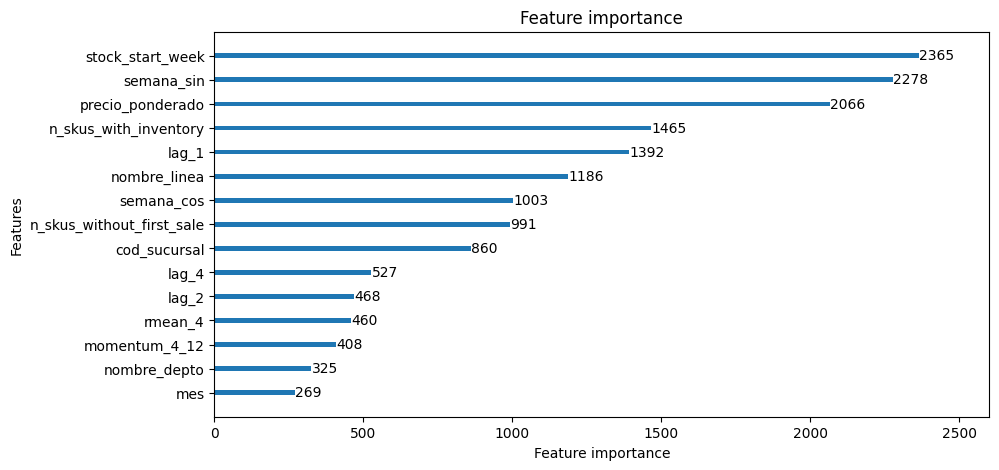

In [31]:
# ===== Predicciones y evaluación =====

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Best iter RMSE: {best_iter} | RMSE validation: {rmse:.4f}")

# ===== Importancia de features =====
ax = lgb.plot_importance(model,max_num_features=15, figsize=(10,5))
ax.set_title("Feature importance")
ax.grid(False)

plt.show()

In [32]:
maestro_producto = load_maestro_producto().collect().to_pandas()

In [70]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Empaquetar resultados en un DataFrame para alinear
pred_df = X_test.copy()
pred_df["real"] = y_test.values
pred_df["predicho"] = y_pred
pred_df["week_start_date"] = df.loc[X_test.index, "week_start_date"]

# Asegurar que week_start_date es datetime
pred_df["week_start_date"] = pd.to_datetime(pred_df["week_start_date"])

# Ordenar por fecha
pred_df = pred_df.sort_values("week_start_date")

pred_df = pred_df[
    (pred_df["nombre_depto"] == "Juvenil mujer") &
    (pred_df["nombre_linea"] == "Poleras manga larga") &
    (pred_df["nombre_temporada"] == "Invierno") &
    (pred_df["cod_talla"] == 105) &
    (pred_df['cod_sucursal'] == 105)
]

In [69]:
testing = pred_df[['nombre_depto', 'nombre_linea','cod_talla','week_start_date','n_skus_with_inventory','real','predicho']].copy()

testing['real_sum_4w'] = (
    testing['real']
    .iloc[::-1]                              # invertir orden
    .rolling(window=4, min_periods=1)        # aplicar rolling
    .sum()
    .iloc[::-1]                              # volver al orden normal
)

# Predicho hacia adelante
testing['predicho_sum_4w'] = (
    testing['predicho']
    .iloc[::-1]
    .rolling(window=4, min_periods=1)
    .sum()
    .iloc[::-1]
)

# Errores con las sumas
testing['error'] = testing['real_sum_4w'] - testing['predicho_sum_4w']
testing['error_abs'] = testing['error'].abs()

# Métricas
wape = testing['error_abs'].sum() / testing['real_sum_4w'].sum()
bias = testing['error'].sum() / testing['real_sum_4w'].sum()

print(f"WAPE: {wape:.4f}")
print(f"Bias: {bias:.4f}")

testing

WAPE: 0.1299
Bias: -0.0192


,nombre_depto,nombre_linea,cod_talla,week_start_date,n_skus_with_inventory,real,predicho,real_sum_4w,predicho_sum_4w,error,error_abs
1247013,Juvenil mujer,Poleras manga larga,105,2025-01-27,2,0,9,12.0,26.0,-14.0,14.0
1247014,Juvenil mujer,Poleras manga larga,105,2025-02-03,2,1,3,36.0,36.0,0.0,0.0
1247015,Juvenil mujer,Poleras manga larga,105,2025-02-10,33,0,4,84.0,67.0,17.0,17.0
1247016,Juvenil mujer,Poleras manga larga,105,2025-02-17,35,11,10,161.0,123.0,38.0,38.0
1247017,Juvenil mujer,Poleras manga larga,105,2025-02-24,50,24,19,249.0,198.0,51.0,51.0
1247018,Juvenil mujer,Poleras manga larga,105,2025-03-03,50,49,34,343.0,339.0,4.0,4.0
1247019,Juvenil mujer,Poleras manga larga,105,2025-03-10,53,77,60,396.0,431.0,-35.0,35.0
1247020,Juvenil mujer,Poleras manga larga,105,2025-03-17,62,99,85,443.0,481.0,-38.0,38.0
1247021,Juvenil mujer,Poleras manga larga,105,2025-03-24,62,118,160,406.0,521.0,-115.0,115.0
1247022,Juvenil mujer,Poleras manga larga,105,2025-03-31,62,102,126,368.0,431.0,-63.0,63.0


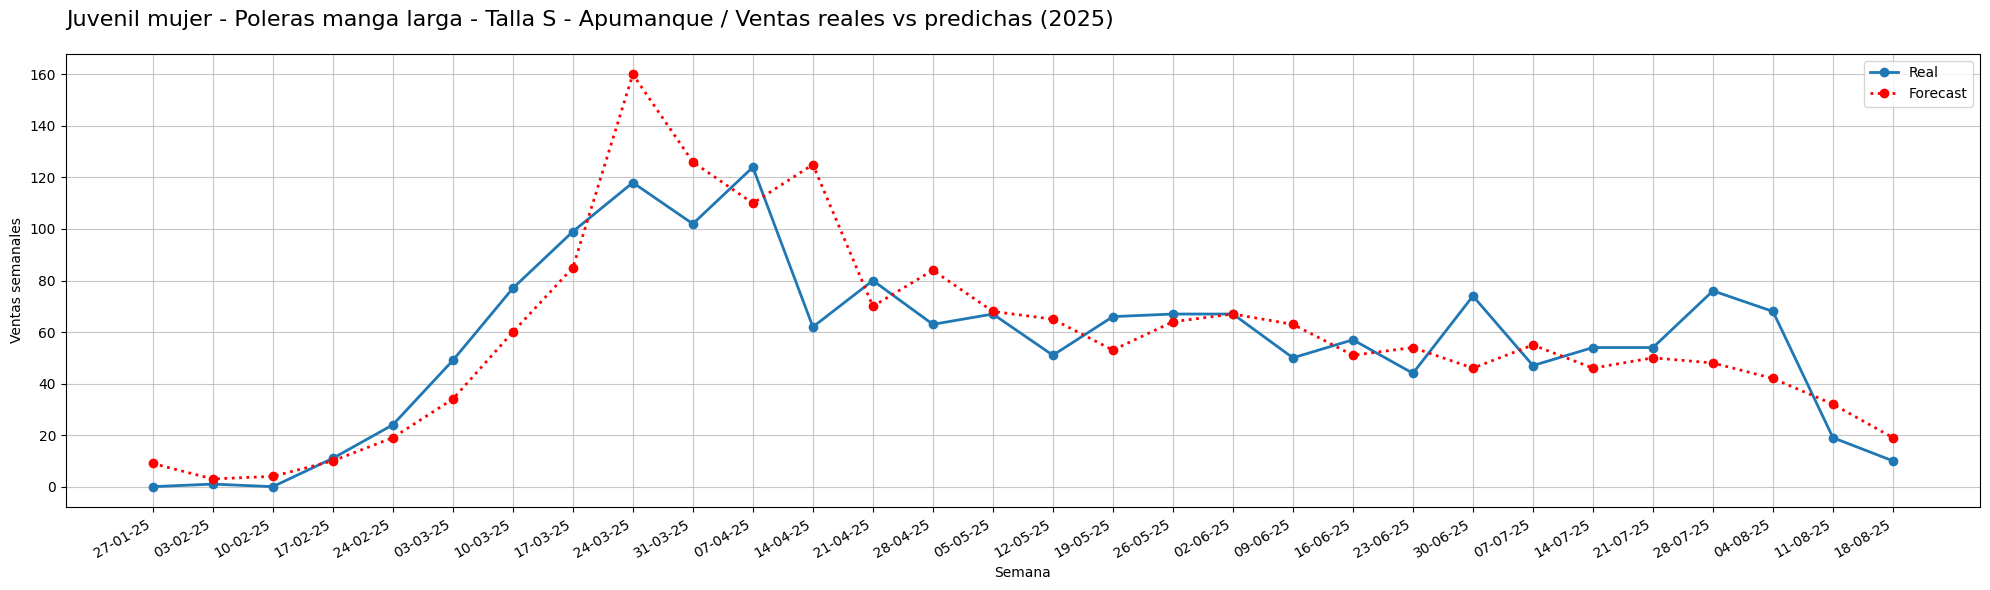

In [81]:

# Gráfico
plt.figure(figsize=(20, 6))
plt.plot(
    testing["week_start_date"], 
    testing["real"], 
    label="Real",
    linewidth=2, 
    marker='o'
)
plt.plot(
    testing["week_start_date"], 
    testing["predicho"], 
    label="Forecast", 
    linewidth=2, 
    linestyle=':', 
    color='red',
    marker='o'
)


# Mostrar todas las semanas con año corto
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.xticks(testing["week_start_date"], rotation=30, ha="right")

plt.xlabel("Semana")
plt.ylabel("Ventas semanales")
plt.title("Juvenil mujer - Poleras manga larga - Talla S - Apumanque / Ventas reales vs predichas (2025)", fontsize=16, pad=20, loc = 'left')
plt.legend()
plt.grid(linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

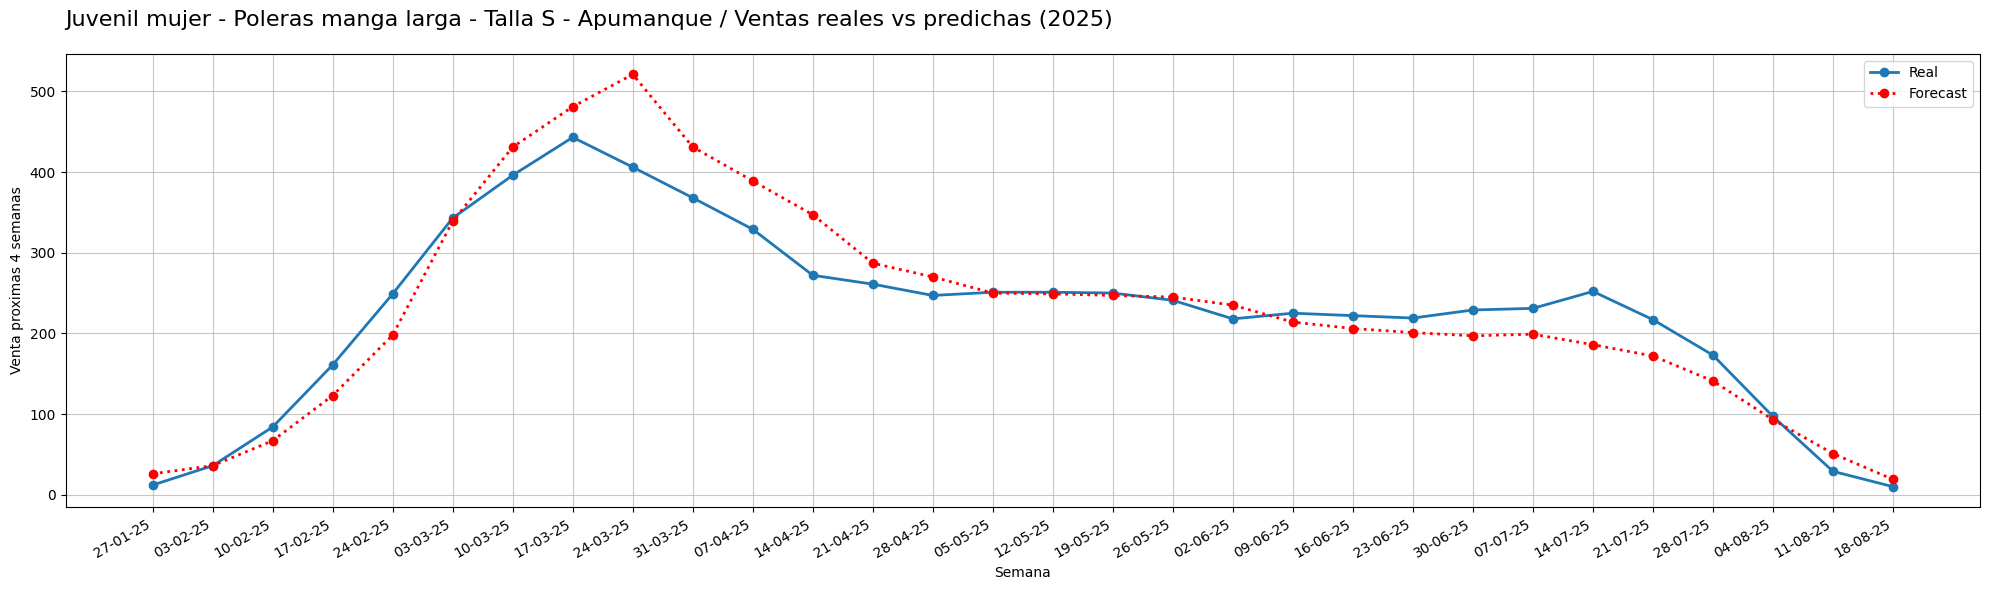

In [80]:
plt.figure(figsize=(20, 6))
plt.plot(
    testing["week_start_date"], 
    testing["real_sum_4w"], 
    label="Real",
    linewidth=2, 
    marker='o'
)
plt.plot(
    testing["week_start_date"], 
    testing["predicho_sum_4w"], 
    label="Forecast", 
    linewidth=2, 
    linestyle=':', 
    color='red',
    marker='o'
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))
plt.xticks(testing["week_start_date"], rotation=30, ha="right")

plt.xlabel("Semana")
plt.ylabel("Venta proximas 4 semanas")
plt.title("Juvenil mujer - Poleras manga larga - Talla S - Apumanque / Ventas reales vs predichas (2025)", fontsize=16, pad=20, loc = 'left')
plt.legend()
plt.grid(linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

def evaluar_forecast(y_real, y_pred):
    # MAE
    mae = mean_absolute_error(y_real, y_pred)
    
    # MAPE (evitando división por cero)
    mask = y_real != 0
    mape = (np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])).mean() * 100
    
    # R²
    r2 = r2_score(y_real, y_pred)
    
    # Interpretaciones
    print(f"MAE:  {mae:.2f} → En promedio el modelo se equivoca en ±{mae:.0f} ventas por semana.")
    print(f"MAPE: {mape:.2f}% → En promedio el error es de {mape:.1f}% respecto a la venta real.")
    print(f"R²:   {r2:.2f} → El modelo explica el {r2*100:.1f}% de la variación semanal de ventas.")

# Uso con tu DataFrame filtrado
evaluar_forecast(pred_df["real"].values, pred_df["predicho"].values)

MAE:  12.97 → En promedio el modelo se equivoca en ±13 ventas por semana.
MAPE: 25.71% → En promedio el error es de 25.7% respecto a la venta real.
R²:   0.67 → El modelo explica el 67.1% de la variación semanal de ventas.
